In [ ]:
import os
import re
import glob
import tifffile as tiff
import numpy as np
import pandas as pd
from skimage.measure import label
from skimage.draw import polygon
from read_roi import read_roi_file   # pip install read-roi

import multiprocessing as mp
from tqdm import tqdm

IMAGE_DIR = "/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images"
base_dir = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/"
CHANNEL_NAMES = {0: "DAPI", 1: "TH", 2: "AT8"}

def find_image_candidates(mask_path):
    mask_root = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/segmentation_3D_masks"
    image_root = "/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images"
    rel_path = os.path.relpath(mask_path, mask_root)
    rel_dir = os.path.dirname(rel_path)
    mask_filename = os.path.basename(mask_path)
    image_stem = re.sub(r'_3D\.tif_indexed\.tif$', '', mask_filename)
    image_path = os.path.join(image_root, rel_dir + ".tif")
    print(image_root)
    print(rel_dir)
    print(f"Looking for image at {image_path}")
    return image_path if os.path.exists(image_path) else None

def load_roi_mask_xy(roi_path, yx_shape):
    """
    Return a 2D boolean mask (Y, X) from an ImageJ .roi file.
    Supports polygon/freehand and rectangle ROIs.
    """
    print(f"Loading ROI from {roi_path}")
    rois = read_roi_file(roi_path)    # dict of name -> roi dict
    if not rois:
        raise ValueError(f"No ROI found in {roi_path}")
    roi = next(iter(rois.values()))
    H, W = yx_shape
    mask_xy = np.zeros((H, W), dtype=bool)

    roi_type = roi.get("type", "").lower()
    if ("x" in roi) and ("y" in roi) and len(roi["x"]) >= 3:
        rr, cc = polygon(roi["y"], roi["x"], (H, W))
        mask_xy[rr, cc] = True
    elif roi_type == "rectangle":
        top = int(roi.get("top", 0))
        left = int(roi.get("left", 0))
        height = int(roi.get("height", 0))
        width = int(roi.get("width", 0))
        mask_xy[top:top+height, left:left+width] = True
    else:
        raise ValueError(f"Unsupported ROI type: {roi_type} in {roi_path}")
    return mask_xy

segmentation_glob = os.path.join(base_dir, "segmentation_3D_masks", "**", "*indexed.tif")
mask_paths = glob.glob(segmentation_glob, recursive=True)

summary_stats = pd.DataFrame(columns=[
    'group', 'age', 'sample_id',
    'n_roi_noncell_voxels', 'n_roi_noncell_nonzero',
    'mean_AT8', 'std_AT8', 'median_AT8', 'AT8_positive_ratio_2std', 'AT8_positive_ratio_mean', 'AT8_positive_ratio_1std', 'total_cells', 'AT8_positive_cells_2std', 'AT8_positive_cells_mean', 'AT8_positive_cells_1std'
])

def process_mask(mask_path):
    try:
        # metadata from path
        pattern = r"/(PS19|Control)\s+Mice/(\d+\s+Months)/(\d+)/"
        match = re.search(pattern, mask_path)
        group = match.group(1) if match else ""
        age = match.group(2) if match else ""
        sample_id = match.group(3) if match else ""

        image_path = find_image_candidates(mask_path)
        if image_path is None:
            print(f"Image not found for mask: {mask_path}")
            return None

        roi_path = image_path.replace(".tif", ".roi")
        if not os.path.exists(roi_path):
            print(f"ROI not found: {roi_path}")
            return None
        

        # load image channel and mask
        image_AT8_channel_index = 2
        img = tiff.imread(image_path)          # expect (Z, C, Y, X) or similar
        img = img[:, image_AT8_channel_index]  # now (Z, Y, X)
        seg = tiff.imread(mask_path)           # expect (Z, Y, X) labels, 0 = non-cell

        if img.shape != seg.shape:
            raise ValueError(f"Shape mismatch image {img.shape} vs mask {seg.shape}")

        # ROI 2D -> broadcast to 3D
        roi_xy = load_roi_mask_xy(roi_path, img.shape[1:])
        roi_3d = np.repeat(roi_xy[None, ...], img.shape[0], axis=0)

        # voxels inside ROI and outside segmentation mask
        roi_noncell = roi_3d & (seg == 0)

        # values to summarize
        vals = img[roi_noncell]
        # vals_nonzero = vals[vals != 0]

        if vals.size == 0:
            mean_at8 = float("nan")
            std_at8 = float("nan")
            median_at8 = float("nan")
        else:
            mean_at8 = float(vals.mean())
            std_at8 = float(vals.std())
            median_at8 = float(np.median(vals))


        cell_intensities_csv_path = re.sub(r'_3D\.tif_indexed\.tif$', '_3D_cell_intensity_stats.csv', mask_path) 
        cell_intensities_csv_path = cell_intensities_csv_path.replace("segmentation_3D_masks", "cell_intensity_stats") 
        cell_intensities_csv_path = os.path.dirname(os.path.dirname(cell_intensities_csv_path)) + '/' + os.path.basename(cell_intensities_csv_path) 
        cell_intensities = pd.read_csv(cell_intensities_csv_path)

        outliers_2std = cell_intensities[cell_intensities['mean_AT8'] > mean_at8 + 2 * std_at8] 
        outliers_mean = cell_intensities[cell_intensities['mean_AT8'] > mean_at8]
        outliers_1std = cell_intensities[cell_intensities['mean_AT8'] > mean_at8 + std_at8]
        num_outliers_2std = len(outliers_2std) / len(cell_intensities)
        num_outliers_mean = len(outliers_mean) / len(cell_intensities)
        num_outliers_1std = len(outliers_1std) / len(cell_intensities)

        
        return {
            'group': group,
            'age': age,
            'sample_id': sample_id,
            'n_roi_noncell_voxels': int(vals.size),
            'n_roi_noncell_nonzero': int(vals.size),
            'mean_AT8': mean_at8,
            'std_AT8': std_at8,
            'median_AT8': median_at8,
            'AT8_positive_ratio_2std': num_outliers_2std,
            'AT8_positive_ratio_mean': num_outliers_mean,
            'AT8_positive_ratio_1std': num_outliers_1std,
            'total_cells': len(cell_intensities),
            'AT8_positive_cells_2std': len(outliers_2std),
            'AT8_positive_cells_mean': len(outliers_mean),
            'AT8_positive_cells_1std': len(outliers_1std),
        }

    except Exception as e:
        print(f"Error processing {mask_path}: {e}")
        return None

# example single file run
# mask_paths = [
    # '/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/segmentation_3D_masks/Control Mice/9 Months/43/43 Slide 1 Section B3/43 Slide 1 Section B3_3D.tif_indexed.tif'
# ]

with mp.Pool(32) as pool:
    results = list(tqdm(pool.imap(process_mask, mask_paths), total=len(mask_paths)))

summary_stats = pd.DataFrame([res for res in results if res is not None])
summary_stats.to_csv(os.path.join(base_dir, "AT8_roi_noncell_summary_new.csv"), index=False)


  0%|          | 0/255 [00:00<?, ?it/s]

/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/media/core/core_operations/ImageAnalysisScratch/Sc

  0%|          | 1/255 [00:03<15:19,  3.62s/it]

/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
PS19 Mice/9 Months/48/48 Slide 2 Section A1
Looking for image at /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/9 Months/48/48 Slide 2 Section A1.tif
Loading ROI from /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/9 Months/45/45 Slide 2 Section C2.roi
/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
PS19 Mice/9 Months/48/48 Slide 1 Section D3
Looking for image at /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/9 Months/48/48 Slide 1 Section D3.tif
/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
PS19 Mice/9 Months/48/48 Slide 2 Section B2
Looking for image at /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/9 Months/48/48 Slide 2 Section B2.tif
/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
PS19

  1%|          | 2/255 [00:04<08:09,  1.94s/it]

...

/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
PS19 Mice/3 Months/240/240 Slide 1 Section D3
Looking for image at /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/3 Months/240/240 Slide 1 Section D3.tif
Loading ROI from /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/3 Months/246/246 Slide 2 Section E1.roi
Loading ROI from /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/3 Months/246/246 Slide 2 Section A1.roi
/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
PS19 Mice/3 Months/247/247 Slide 2 Section E1
Looking for image at /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/3 Months/247/247 Slide 2 Section E1.tif
Loading ROI from /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/3 Months/240/240 Slide 1 Section B3.roi
/media/core/core_operations/ImageAnalysisScratc

 32%|███▏      | 81/255 [00:13<00:22,  7.63it/s]

/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
Control Mice/7 Months/74/74 Slide 1 Section C2
Looking for image at /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/Control Mice/7 Months/74/74 Slide 1 Section C2.tif
/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
Control Mice/9 Months/69/69 Slide 2 Section A2
Looking for image at /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/Control Mice/9 Months/69/69 Slide 2 Section A2.tif
Loading ROI from /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/Control Mice/7 Months/74/74 Slide 1 Section C2.roi
Loading ROI from /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/Control Mice/7 Months/74/74 Slide 1 Section D2.roi
Loading ROI from /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/Control Mice/7 Months/74/74 Slide 1 Section E3.roi
Loading ROI from /media/core/core_operat

 33%|███▎      | 83/255 [00:15<00:28,  5.98it/s]

/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
Control Mice/9 Months/137/137 Slide 1 Section C2
Looking for image at /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/Control Mice/9 Months/137/137 Slide 1 Section C2.tif
/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
Control Mice/9 Months/137/137 Slide 1 Section A3
Looking for image at /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/Control Mice/9 Months/137/137 Slide 1 Section A3.tif
/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
Control Mice/9 Months/137/137 Slide 1 Section B3
Looking for image at /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/Control Mice/9 Months/137/137 Slide 1 Section B3.tif
/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images
Control Mice/9 Months/137/137 Slide 1 Section B2
Looking for image at /media/core/core_operations/ImageAnalysisSc

In [26]:
summary_stats

,group,age,sample_id,n_roi_noncell_voxels,n_roi_noncell_nonzero,mean_AT8,std_AT8,median_AT8,AT8_positive_ratio_2std,AT8_positive_ratio_mean,AT8_positive_ratio_1std
0,PS19,4 Months,187,17580034,17580034,180.511045,53.407781,166.0,0.201946,0.722628,0.437956
1,PS19,4 Months,187,27269583,27269583,155.709604,31.403724,150.0,0.108696,0.813665,0.456522
2,PS19,4 Months,187,8811081,8811081,172.216719,42.527021,163.0,0.090909,0.727273,0.400826
3,PS19,4 Months,187,4701072,4701072,218.448140,86.775928,194.0,0.148649,0.695946,0.405405
4,PS19,4 Months,187,27022055,27022055,155.344673,35.102424,149.0,0.194842,0.808023,0.449857
...,...,...,...,...,...,...,...,...,...,...,...
225,Control,3 Months,244,10083844,10083844,159.892538,23.156923,158.0,0.009009,0.837838,0.238739
226,Control,3 Months,244,30927146,30927146,148.061479,19.931908,147.0,0.020930,0.544186,0.165116
227,Control,3 Months,244,5146248,5146248,167.505010,26.523459,165.0,0.014815,0.881481,0.362963
228,Control,3 Months,244,4172935,4172935,159.541227,26.298567,157.0,0.010753,0.838710,0.365591


In [ ]:
import os
import re
import glob
import tifffile as tiff
import numpy as np
import pandas as pd
from skimage.measure import label
from skimage.draw import polygon
from read_roi import read_roi_file   # pip install read-roi

import multiprocessing as mp
from tqdm import tqdm
base_dir = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/"
summary_stats = pd.read_csv(os.path.join(base_dir, "AT8_roi_noncell_summary_new.csv"))

In [25]:
summary_stats

,group,age,sample_id,n_roi_noncell_voxels,n_roi_noncell_nonzero,mean_AT8,std_AT8,median_AT8,AT8_positive_ratio_2std,AT8_positive_ratio_mean,AT8_positive_ratio_1std
0,PS19,4 Months,187,17580034,17580034,180.511045,53.407781,166.0,0.201946,0.722628,0.437956
1,PS19,4 Months,187,27269583,27269583,155.709604,31.403724,150.0,0.108696,0.813665,0.456522
2,PS19,4 Months,187,8811081,8811081,172.216719,42.527021,163.0,0.090909,0.727273,0.400826
3,PS19,4 Months,187,4701072,4701072,218.448140,86.775928,194.0,0.148649,0.695946,0.405405
4,PS19,4 Months,187,27022055,27022055,155.344673,35.102424,149.0,0.194842,0.808023,0.449857
...,...,...,...,...,...,...,...,...,...,...,...
225,Control,3 Months,244,10083844,10083844,159.892538,23.156923,158.0,0.009009,0.837838,0.238739
226,Control,3 Months,244,30927146,30927146,148.061479,19.931908,147.0,0.020930,0.544186,0.165116
227,Control,3 Months,244,5146248,5146248,167.505010,26.523459,165.0,0.014815,0.881481,0.362963
228,Control,3 Months,244,4172935,4172935,159.541227,26.298567,157.0,0.010753,0.838710,0.365591


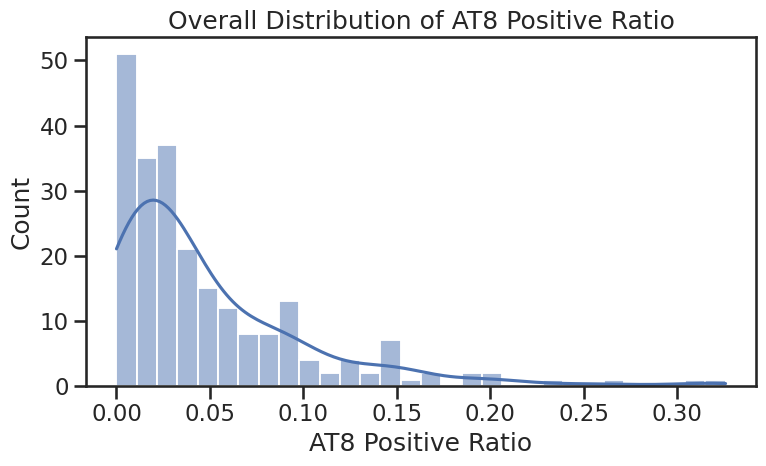

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

STAT = '2std'

sns.set(style="ticks", context="talk")
plt.figure(figsize=(8, 5))
sns.histplot(summary_stats[f"AT8_positive_ratio_{STAT}"], kde=True, bins=30)
plt.title("Overall Distribution of AT8 Positive Ratio")
plt.xlabel("AT8 Positive Ratio")
plt.ylabel("Count")
plt.tight_layout()
# plt.show()
# plt.savefig(f"/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/fig/AT8_positive_ratio_distribution_{STAT}.png", dpi=300)


ANOVA: F = 52.060, p = 7.905e-12
Kruskal–Wallis: H = 73.225, p = 1.157e-17


/tmp/ipykernel_3240501/783587232.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=summary_stats, x="group", y=f"AT8_positive_ratio_{STAT}", palette="Set2")


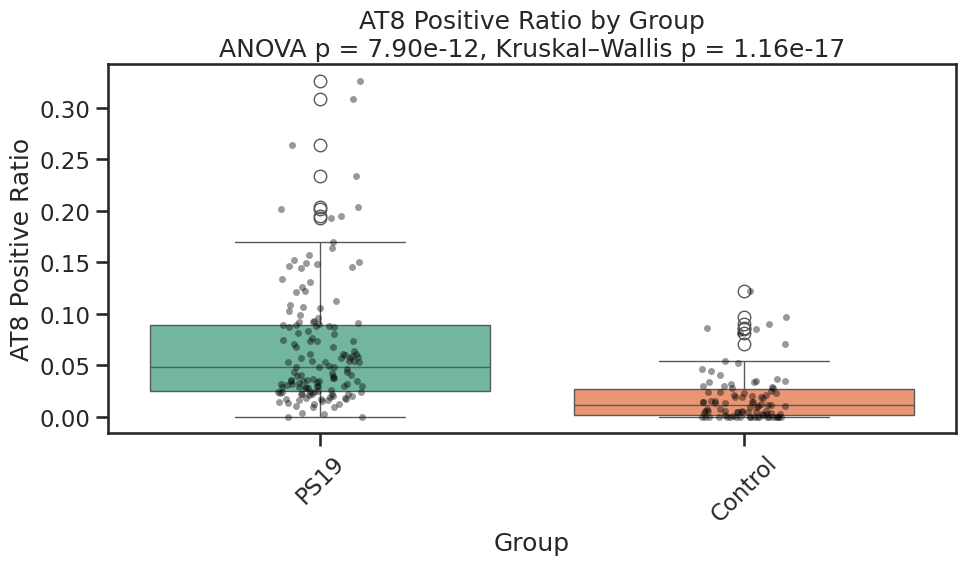

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, kruskal

sns.set(style="ticks", context="talk")

# --- 1. Compute statistical significance across groups ---
groups = [g[f"AT8_positive_ratio_{STAT}"].dropna() for _, g in summary_stats.groupby("group")]

# Perform ANOVA (parametric)
anova = f_oneway(*groups)
anova_p = anova.pvalue

# Perform Kruskal–Wallis (non-parametric)
kw = kruskal(*groups)
kw_p = kw.pvalue

print(f"ANOVA: F = {anova.statistic:.3f}, p = {anova_p:.3e}")
print(f"Kruskal–Wallis: H = {kw.statistic:.3f}, p = {kw_p:.3e}")

# --- 2. Annotate the p-values on the boxplot ---
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=summary_stats, x="group", y=f"AT8_positive_ratio_{STAT}", palette="Set2")
sns.stripplot(data=summary_stats, x="group", y=f"AT8_positive_ratio_{STAT}",
              color="black", alpha=0.4, jitter=True)

# Add a title that includes p-values
plt.title(
    f"AT8 Positive Ratio by Group\n"
    f"ANOVA p = {anova_p:.2e}, Kruskal–Wallis p = {kw_p:.2e}"
)
plt.xlabel("Group")
plt.ylabel("AT8 Positive Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
# plt.show()
plt.savefig(f"/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/fig/AT8_positive_ratio_boxplot_{STAT}.png", dpi=300)

/tmp/ipykernel_3240501/4060939101.py:54: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_3240501/4060939101.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats


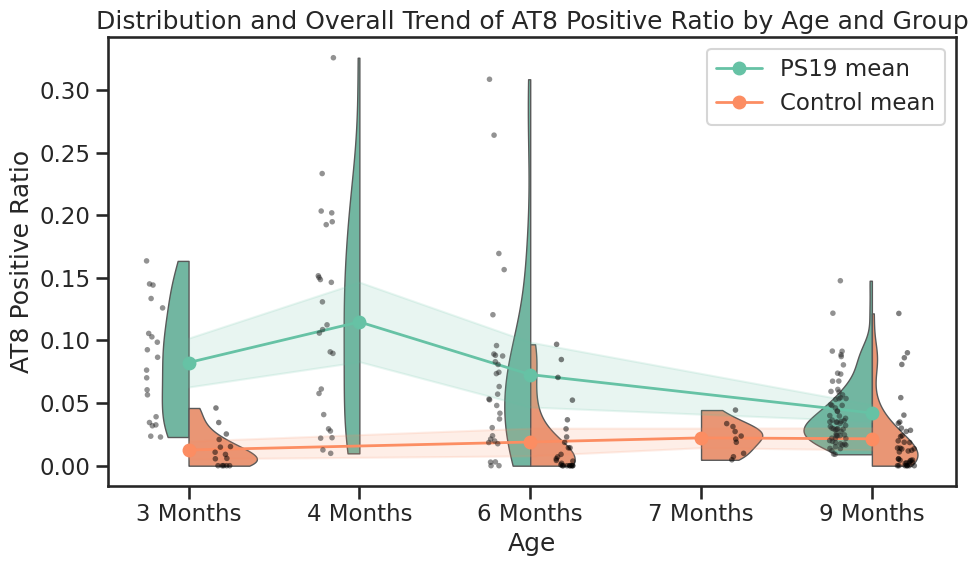

In [13]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="ticks", context="talk")

# --- Convert age strings to numeric months ---
def parse_age_to_months(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    m = re.search(r'(\d+(?:\.\d+)?)\s*(year|years|yr|yrs|month|months|mo|mos)?', s)
    if not m:
        return np.nan
    val = float(m.group(1))
    unit = m.group(2) or 'months'
    return val * 12.0 if unit.startswith('y') else val

summary_stats['age_months'] = summary_stats['age'].apply(parse_age_to_months)

# --- Order ages chronologically ---
age_order = (
    summary_stats
    .groupby('age', dropna=False)['age_months']
    .mean()
    .sort_values()
    .index
)

summary_stats['age_ordered'] = pd.Categorical(
    summary_stats['age'],
    categories=age_order,
    ordered=True
)

# --- Base violin plot (split by group) ---
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=summary_stats,
    x="age_ordered",
    y=f"AT8_positive_ratio_{STAT}",
    hue="group",
    split=True,
    inner=None,
    cut=0,
    linewidth=1.0,
    palette="Set2",
    legend=False
)

# --- Overlay jittered sample dots ---
sns.stripplot(
    data=summary_stats,
    x="age_ordered",
    y=f"AT8_positive_ratio_{STAT}",
    hue="group",
    dodge=True,
    alpha=0.5,
    size=4,
    color="black",
    legend=False
)


# --- Compute group-wise means and 95% CI for trend lines ---
agg = (
    summary_stats
    .groupby(["group", "age_ordered"], dropna=False)[f"AT8_positive_ratio_{STAT}"]
    .agg(mean="mean", sd="std", n="size")
    .reset_index()
)
agg["se"] = agg["sd"] / np.sqrt(agg["n"].replace(0, np.nan))
agg["ci_low"] = agg["mean"] - 1.96 * agg["se"]
agg["ci_high"] = agg["mean"] + 1.96 * agg["se"]

# --- Map categorical ages to numeric x positions ---
age_levels = list(summary_stats["age_ordered"].cat.categories)
x_pos = {cat: i for i, cat in enumerate(age_levels)}
agg["x"] = agg["age_ordered"].map(x_pos)

# --- Same color palette as the violins ---
groups = ['PS19', 'Control']
palette = sns.color_palette("Set2", n_colors=len(groups))
color_map = dict(zip(groups, palette))

# --- Overlay mean trend lines + CI ribbons ---
for g in groups:
    d = agg[agg["group"] == g].sort_values("x")
    d = d.dropna(subset=["x", "mean"])
    if d.empty:
        continue
    plt.fill_between(d["x"], d["ci_low"], d["ci_high"], alpha=0.15, color=color_map[g])
    plt.plot(d["x"], d["mean"], marker="o", linewidth=2, color=color_map[g], label=f"{g} mean")

# --- Tidy up axis and legend ---
plt.xticks(range(len(age_levels)), age_levels)
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), loc='upper right', title=None)

plt.xlabel("Age")
plt.ylabel("AT8 Positive Ratio")
plt.title("Distribution and Overall Trend of AT8 Positive Ratio by Age and Group")
plt.tight_layout()
# plt.show()
plt.savefig(f"/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/fig/AT8_positive_ratio_trend_by_age_{STAT}.png", dpi=300)


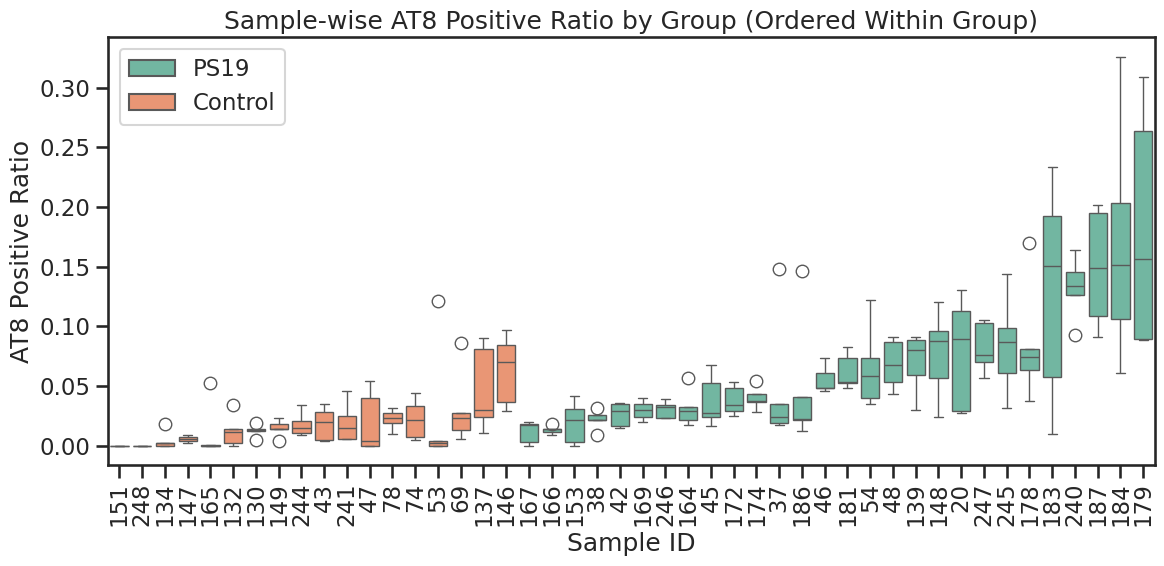

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="ticks", context="talk")

# --- Compute mean AT8 ratio per sample within each group ---
mean_order = (
    summary_stats
    .groupby(["group", "sample_id"], dropna=False)[f"AT8_positive_ratio_{STAT}"]
    .mean()
    .reset_index()
)

# For each group, sort samples by mean
ordered_samples = (
    mean_order
    .sort_values(["group", f"AT8_positive_ratio_{STAT}"], ascending=[True, True])
    .groupby("group")["sample_id"]
    .apply(list)
    .to_dict()
)

# --- Create a single ordered list that respects group-wise ordering ---
ordered_sample_list = []
for g in sorted(ordered_samples.keys()):
    ordered_sample_list.extend(ordered_samples[g])

# --- Plot with custom order ---
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=summary_stats,
    x="sample_id",
    y=f"AT8_positive_ratio_{STAT}",
    hue="group",
    order=ordered_sample_list,
    palette="Set2"
)

plt.title("Sample-wise AT8 Positive Ratio by Group (Ordered Within Group)")
plt.xlabel("Sample ID")
plt.ylabel("AT8 Positive Ratio")
plt.xticks(rotation=90)
plt.legend(loc='upper left', title=None)
plt.tight_layout()
# plt.show()
plt.savefig(f"/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/fig/AT8_positive_ratio_boxplot_sample_{STAT}.png", dpi=300)
